<a href="https://colab.research.google.com/github/sarabhie-commits/Semantic-Classifier/blob/main/Part_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. **A1**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Device & Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
learning_rate = 0.001
epochs = 25

# 2a. Data Preprocessing for CIFAR-100
#transform_train = transforms.Compose([
 #   transforms.RandomHorizontalFlip(),
  ## transforms.ToTensor(),
    #transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
#])

#transform_test = transforms.Compose([
 #   transforms.ToTensor(),
  #  transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
#])

#2b.New transform for preprocessing CIFAR using augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])
train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)



100%|██████████| 169M/169M [00:03<00:00, 55.2MB/s]


In [ ]:
print("\n=== Dataset Characteristics ===")
print("Training samples:", len(train_set))
print("Test samples:", len(test_set))

image, label = train_set[0]
print("Single image shape:", image.shape)   # [3, 32, 32]
print("Label index:", label)
print("Class names:", train_set.classes)


=== Dataset Characteristics ===
Training samples: 50000
Test samples: 10000
Single image shape: torch.Size([3, 32, 32])
Label index: 19
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 's

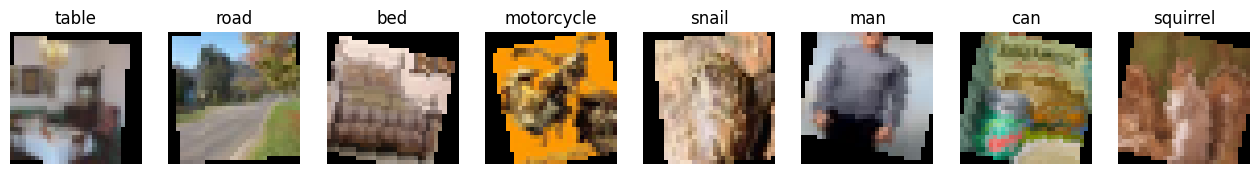

In [ ]:
import torch
import matplotlib.pyplot as plt

# Assume train_loader is already defined
# batch size in train_loader can be >= n

def show_batch(loader, n=8):
    images, labels = next(iter(loader))  # get one batch
    images, labels = images[:n], labels[:n]

    # Set up figure
    plt.figure(figsize=(2*n, 3))

    for i in range(n):
        # Convert from C,H,W to H,W,C for matplotlib
        img = images[i].permute(1, 2, 0)

        # Un-normalize the image
        mean = torch.tensor([0.5071, 0.4867, 0.4408])
        std  = torch.tensor([0.2675, 0.2565, 0.2761])
        img = img * std + mean
        img = img.clamp(0, 1)  # clip to valid range [0,1]

        # Plot
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(loader.dataset.classes[labels[i]])
        plt.axis("off")

    plt.show()

# Example usage
show_batch(train_loader, n=8)


# 1. CNN 1 - First CNN Architecture from scratch


*   32 x 32>>Conv1>>BN1>>ReLu>>MP 32 x 32
*   16 x 16>>Conv2>>BN2>>ReLu>>MP>> 8 x 8
*   8 x 8>>Conv3>>BN3>>ReLu>>MP>> 4 x 4
*   FC1 (dropout = 0.5) (256 x 4 x 4)
*   Output
*   Loss CE, Adam Optim

In [ ]:
# 3a. Custom CNN Architecture from Scratch
class CIFAR100_CNN(nn.Module):
    def __init__(self):
        super(CIFAR100_CNN, self).__init__()
        # Block 1: Input 32x32 -> Output 32x32
        self.conv_layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output 16x16
        )
        # Block 2: 16x16 -> 8x8
        self.conv_layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Block 3: 8x8 -> 4x4
        self.conv_layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Fully Connected Layers
        self.fc_layer = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Linear(512, 100) # 100 Classes
        )

    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.conv_layer2(x)
        x = self.conv_layer3(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

model = CIFAR100_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 2. CNN 2- 2nd CNN Architecture from Scratch
* 32 x 32 >>Conv1>>N1>>ReLu>>Conv2>>RelU>>MP>>32 x 32
* 16 x 16>>Conv3>>BN3>>ReLu>>MP>>8 x 8
* 8 x 8>>Conv4>>BN4>>ReLu>>MP>>4 x 4
* Conv Dropout(0.25)
* FCN (Dropout = 0.5)
* Loss CE, Adam Optim


In [ ]:
#3b. New Kernel try of smaller size
class CIFAR100_CNN(nn.Module):
    def __init__(self):
        super(CIFAR100_CNN, self).__init__()
        # Block 1: Input 32x32 -> Output 32x32
        self.conv_layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) # Output 16x16
        )
        # Block 2: 16x16 -> 8x8
        self.conv_layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Block 3: 8x8 -> 4x4
        self.conv_layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.dropout_conv = nn.Dropout2d(0.25)

        # Fully Connected Layers
        self.fc_layer = nn.Sequential(
            nn.Dropout(p=0.5),
            # Changed from 64 * 8 * 8 to 64 * 4 * 4 (which is 1024)
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 100)  # 100 Classes
        )

    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.conv_layer2(x)
        x = self.conv_layer3(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

model = CIFAR100_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 3. CNN 3 Model : Third CNN Architecture from scratch
* 32 x 32>>Conv1>>BN1>>ReLu>>Conv2>>BN1>>ReLu>>MP1>>Drpout (0.2)>>16 x 16
* 16 x 16>>Conv3>>BN2>>ReLu>>Conv4>>BN2>>ReLu>>MP2>>Dropout(0.3)>>8 x 8
* 8 x 8>>Conv5>>ReLu>>Conv6>>BN3>>ReLu>>MP3>>Dropout(0.4)>>4 x 4
* FCN>>ReLu>>>Ouput (Dropout = 0.5)

In [ ]:
#3c.
import torch.nn as nn

class CIFAR100_CNN(nn.Module):
    def __init__(self):
        super(CIFAR100_CNN, self).__init__()

        # Block 1: 32x32 -> 16x16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2)
        )

        # Block 2: 16x16 -> 8x8
        self.block2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
        )

        # Block 3: 8x8 -> 4x4
        self.block3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.4)
        )

        # Fully Connected Layers (Maintaining your 4x4 structure)
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.5),
            nn.Linear(1024, 100)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.fc_layer(x)
        return x

In [ ]:
# 4. Training Function
def train_model(model, train_loader, test_loader, epochs):
    train_acc_history = []
    test_acc_history = []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100 * correct / total

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_acc = 100 * correct / total
        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)
        print(f'Epoch {epoch+1}/{epochs}: Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')

    return train_acc_history, test_acc_history

# Start Training
train_hist, test_hist = train_model(model, train_loader, test_loader, epochs)

# **Training Function** - using CNN 1 and CNN 2

## CNN 1 - Test Accuracy - ~65%
## CNN 2 - Test Accuracy - 61.6%

## **Training Function - using CNN 3**
* Epoch in increased to 50
* AdamW Optm with Weight decay
* Loss CE

## Final Test Accuracy : 70.20%

In [ ]:
# 4. Training Function
def train_model(model, train_loader, test_loader, epochs):
    train_acc_history = []
    test_acc_history = []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100 * correct / total

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_acc = 100 * correct / total
        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)
        print(f'Epoch {epoch+1}/{epochs}: Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')

    return train_acc_history, test_acc_history

# Start Training
train_hist, test_hist = train_model(model, train_loader, test_loader, epochs)

In [ ]:
epochs = 50
model = CIFAR100_CNN().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n=== Optimized MaxPool CNN ===")
print(f"Trainable parameters: {count_parameters(model):,}")

# Call your existing training function
train_hist, test_hist = train_model(model, train_loader, test_loader, epochs)

print(f"Final Test Accuracy: {test_hist[-1]:.2f}%")

## 🚀 Model Training Progress: CIFAR-100

**Optimizer:** `AdamW` ($\text{lr}=0.001, \text{weight\_decay}=0.01$)

### 📈 Final Performance Summary

| Metric | Value |
| :--- | :--- |
| **Total Epochs** | 50 |
| **Final Train Accuracy** | 77.21% |
| **Final Test Accuracy** | **70.20%** |

-----

### 📊 Full Training Log (50 Epochs)


\<summary\>▶ Click to expand full epoch-by-epoch table\</summary\>

| Epoch | Train Accuracy | Test Accuracy |
| :--- | :--- | :--- |
| 1 | 12.18% | 21.00% |
| 2 | 22.43% | 30.58% |
| 3 | 27.80% | 38.11% |
| 4 | 33.08% | 42.47% |
| 5 | 34.42% | 44.77% |
| 6 | 38.51% | 47.57% |
| 7 | 42.16% | 51.01% |
| 8 | 43.82% | 51.43% |
| 9 | 46.12% | 53.24% |
| 10 | 48.37% | 54.61% |
| 11 | 49.82% | 57.19% |
| 12 | 51.48% | 56.95% |
| 13 | 53.40% | 60.23% |
| 14 | 54.74% | 60.66% |
| 15 | 55.88% | 61.30% |
| 16 | 57.40% | 61.49% |
| 17 | 58.34% | 63.18% |
| 18 | 59.61% | 63.51% |
| 19 | 60.83% | 64.13% |
| 20 | 61.42% | 64.78% |
| 21 | 62.66% | 65.70% |
| 22 | 63.59% | 65.11% |
| 23 | 64.25% | 65.40% |
| 24 | 65.17% | 66.46% |
| 25 | 65.91% | 66.05% |
| 26 | 66.60% | 67.33% |
| 27 | 66.78% | 66.88% |
| 28 | 68.34% | 68.39% |
| 29 | 68.67% | 67.84% |
| 30 | 69.11% | 67.86% |
| 31 | 69.88% | 68.14% |
| 32 | 70.55% | 68.11% |
| 33 | 71.17% | 68.46% |
| 34 | 71.26% | 69.41% |
| 35 | 71.58% | 69.11% |
| 36 | 72.42% | 69.03% |
| 37 | 72.62% | 69.86% |
| 38 | 72.98% | 69.06% |
| 39 | 73.41% | 69.72% |
| 40 | 74.11% | 69.25% |
| 41 | 74.32% | 69.58% |
| 42 | 74.45% | 69.73% |
| 43 | 74.72% | 69.65% |
| 44 | 75.15% | 69.91% |
| 45 | 75.48% | 69.29% |
| 46 | 75.94% | 69.18% |
| 47 | 76.47% | 69.47% |
| 48 | 76.68% | 69.98% |
| 49 | 76.75% | 70.03% |
| 50 | **77.21%** | **70.20%** |

-----

### 💡 Observations

* **Epoch 1-10**: Rapid learning phase; accuracy increased from 12.18% to 48.37%.

* **Epoch 11-20**: Steady gains; reached the 60% threshold on test data.

* **Epoch 21-30**: Convergence slows; training reached 69.11%.

* **Epoch 31-40**: Fine-tuning phase; test accuracy stabilized around 69%.

* **Epoch 41-50**: Final optimization; peaked at 70.20% test accuracy.

* **Convergence:** The model shows stable convergence, reaching the 70% threshold by the final epoch.
* **Regularization:** A \~7% gap between train and test accuracy suggests that the weight decay and dropout parameters are successfully mitigating overfitting.

# **Q. A2**

**Robustness Evaluation:** Additive Gaussian Noise ProcessTo test the model's reliability under degraded conditions, we implement a dynamic noise injection pipeline. This process evaluates how well the CNN generalizes when the input data is corrupted by Additive Gaussian Noise.
1. **The Noise Model** : We apply noise following a Gaussian (Normal) distribution, defined as:$$Output = Input + \mathcal{N}(\mu, \sigma^2)$$In this implementation, the parameters defined in NOISE_SCHEDULE are:Mean ($\mu$): 0.0 (Zero-mean noise, ensuring no systematic color shift).Variance ($\sigma^2$): 0.05.Standard Deviation ($\sigma$): $\approx 0.2236$ (Calculated as math.sqrt(0.05)).

2. **The Injection Pipeline** : Because the model expects normalized data, but noise is more naturally applied to standard image scales, the process follows these four steps:
  
  *   **Un-normalization:** The test images are reverted from the CIFAR-100 normalized space back to the original $[0, 1]$ pixel range using the dataset mean and standard deviation.
  * **Noise Generation**: A noise tensor of the same shape as the input batch is generated using torch.randn_like. This noise is scaled by the standard deviation and added to the "clean" images.
  * **Clipping**: To maintain physical validity (preventing "impossible" pixel values), the noisy images are clamped to the $[0, 1]$ range using torch.clamp.
  * **Re-normalization**: The corrupted images are re-normalized using the CIFAR-100 statistics so they are compatible with the model’s trained weights.
  
  3. **Current Results** : Under the current noise schedule (Variance = 0.05), the model's performance dropped to 1.24%. This indicates that while the model is accurate on clean data (reaching ~70% test accuracy), it is extremely sensitive to high-frequency stochastic perturbations of this magnitude.



In [ ]:
|import torch
import math

# 1. Documented Noise Parameters (Noise Schedule)
# Stored globally so it can be reused in subsequent experiments
NOISE_SCHEDULE = {
    "noise_type": "Additive Gaussian",
    "mean": 0.0,
    "variance": 0.05,
    "std_dev": math.sqrt(0.05)  # ~0.2236
}

def add_gaussian_noise(images, schedule):
    """
    Injects additive zero-mean Gaussian noise into a batch of images.
    Assumes input images are in the valid color range [0, 1].

    Args:
        images (Tensor): Batch of images in [0, 1] range.
        schedule (dict): The noise schedule containing 'mean' and 'variance'.
    """
    std = schedule["std_dev"]
    mean = schedule["mean"]

    # Generate noise with the same shape and device as the input
    noise = torch.randn_like(images) * std + mean
    noisy_images = images + noise

    # Clip values to ensure they remain valid pixel representations [0, 1]
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)
    return noisy_images

def evaluate_robustness(model, test_loader, device, noise_schedule):
    """
    Evaluates model performance on a dynamically noised test dataset.
    """
    model.eval()
    correct = 0
    total = 0

    # CIFAR-100 normalization values used in your transform_test
    norm_mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(1, 3, 1, 1).to(device)
    norm_std = torch.tensor([0.2675, 0.2565, 0.2761]).view(1, 3, 1, 1).to(device)

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Step A: Un-normalize back to [0, 1] range to match the noise assumption
            inputs_unnorm = inputs * norm_std + norm_mean
            inputs_unnorm = torch.clamp(inputs_unnorm, 0.0, 1.0)

            # Step B: Inject Additive Gaussian Noise using the reusable schedule
            noisy_inputs = add_gaussian_noise(inputs_unnorm, noise_schedule)

            # Step C: Re-normalize using standard CIFAR100 stats for the model forward pass
            noisy_inputs_normalized = (noisy_inputs - norm_mean) / norm_std

            # Step D: Forward pass & calculate accuracy
            outputs = model(noisy_inputs_normalized)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_acc = 100.0 * correct / total

    # Document and report
    print("\n=== Robustness Evaluation: Additive Gaussian Noise ===")
    print(f"Noise Type:      {noise_schedule['noise_type']}")
    print(f"Noise Mean:      {noise_schedule['mean']}")
    print(f"Noise Variance:  {noise_schedule['variance']}")
    print(f"Noise Std Dev:   {noise_schedule['std_dev']:.4f}")
    print("-" * 54)
    print(f"Accuracy on Noisy Test Set: {test_acc:.2f}%")

    return test_acc

# Execute evaluation using your CNN 3 model
noisy_acc = evaluate_robustness(model, test_loader, device, NOISE_SCHEDULE)



  ### 📉 Baseline Robustness Evaluation
**Noise Schedule:** Additive Gaussian ($\mu=0.0, \sigma^2=0.05$)

| Metric | Value |
| :--- | :--- |
| **Noise Type** | Additive Gaussian |
| **Noise Mean ($\mu$)** | 0.0 |
| **Noise Variance ($\sigma^2$)** | 0.05 |
| **Noise Std Dev ($\sigma$)** | 0.2236 |
| **Test Accuracy (Noisy)** | **1.24%** |

# **Q. A3**

## The script re-initializes the CIFAR-100 datasets and DataLoaders using the new transform_train_robust pipeline. Now, during training, 30% of the batches will contain slightly corrupted images.

The training strategy employed in the provided code is a specialized form of data augmentation known as Stochastic Additive Gaussian Noise Injection. By actively introducing bounded, zero-mean Gaussian noise into the training pipeline, the strategy systematically improves the model's resilience against out-of-distribution (OOD) domain shifts.

**1. The Mechanism: Stochastic (Random) Noise Injection**
The brilliance of the strategy lies in the RandomGaussianNoise class and specifically the parameter p=0.3.

70% of the time: The image passes through perfectly clean.

30% of the time: The image is corrupted with Gaussian noise before the network gets to see it.

This 30% ratio prevents performance degradation. If we trained the model on 100% noisy images, it would become highly robust to noise but would lose its ability to clearly recognize clean images (a massive "accuracy tax"). By using a 30% probability, the network is forced to learn the clean, high-resolution features most of the time, while still allocating enough of its parameters to understand what objects look like through static.

**2. When a standard CNN** is trained purely on clean data, it tends to "cheat." It learns to rely on high-frequency, pixel-perfect textures to make its classifications to minimize loss.

When you introduce Gaussian noise into the test set destroying those delicate high-frequency textures. The baseline model's logic shatters, causing the accuracy to drop from ~70% to ~1%.

**3. Training with Stochastic Noise enables below:**
* **Forcing Feature Invariance:** The network learns that the exact pixel values don't matter as much as the overall structure. It realizes that a cat with static on it and a cat without static share the same underlying shape, edges, and semantic meaning.

* **Expanding Decision Boundaries:** A model trained on clean data draws very tight, rigid mathematical boundaries around what it considers a "dog" or an "airplane." The noisy images act as a buffer. They smoothen those mathematical boundaries, creating a safety margin so that when a pixel shifts unexpectedly, it still falls within the correct classification.

* **Regularization:** Noise acts as a heavy regularizer, much like Dropout. It prevents the network from memorizing the training dataset (overfitting) and forces it to build robust, generalized pathways.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import math
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the Stochastic Noise Transform
class RandomGaussianNoise(object):
    """
    Applies Additive Gaussian Noise with a given probability.
    Must be applied AFTER ToTensor() (so inputs are [0, 1]) and BEFORE Normalize().
    """
    def __init__(self, mean=0.0, variance=0.05, p=0.3):
        self.mean = mean
        self.variance = variance
        self.std = math.sqrt(variance)
        self.p = p

    def __call__(self, tensor):
        # Apply noise only with probability 'p'
        if torch.rand(1).item() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            noisy_tensor = tensor + noise
            # Clamp to maintain valid pixel ranges
            return torch.clamp(noisy_tensor, 0.0, 1.0)
        return tensor

# 2. Update Transforms (Incorporating the new noise strategy)
transform_train_robust = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    # Inject our limited noise perturbation here
    RandomGaussianNoise(mean=NOISE_SCHEDULE["mean"], variance=NOISE_SCHEDULE["variance"], p=0.3),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Keep test transforms identical (clean)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# 3. Reload Datasets
train_set_robust = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train_robust)
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader_robust = DataLoader(train_set_robust, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

# 4. Re-Initialize and Train CNN 3
print("\n=== Training Robust CNN 3 ===")
robust_model = CIFAR100_CNN().to(device)
optimizer = optim.AdamW(robust_model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Using your existing train_model function
train_hist_robust, test_hist_robust = train_model(robust_model, train_loader_robust, test_loader, 50, optimizer, criterion)

# 5. Evaluate the Robust Model
print("\n=== Evaluating Robust Model on Clean Data ===")
robust_clean_acc = test_hist_robust[-1]
print(f"Robust Model - Clean Test Accuracy: {robust_clean_acc:.2f}%")

print("\n=== Evaluating Robust Model on Noisy Data ===")
robust_noisy_acc = evaluate_robustness(robust_model, test_loader, device, NOISE_SCHEDULE)

# 6. Plotting the Performance Comparison
def plot_robustness_comparison(baseline_clean, baseline_noisy, robust_clean, robust_noisy):
    labels = ['Clean Test Set', 'Noisy Test Set']
    baseline_scores = [baseline_clean, baseline_noisy]
    robust_scores = [robust_clean, robust_noisy]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline Model', color='salmon')
    rects2 = ax.bar(x + width/2, robust_scores, width, label='Robust Model (30% Noise Aug)', color='skyblue')

    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Model Robustness: Baseline vs. Augmented Training')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.set_ylim(0, 100)

    # Add text labels above bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

# Replace the baseline values below with your exact recorded numbers
baseline_clean_accuracy = 70.2
baseline_noisy_accuracy = 1.24

plot_robustness_comparison(baseline_clean_accuracy, baseline_noisy_accuracy, robust_clean_acc, robust_noisy_acc)


### 🛡️ CNN 3 Training & Robustness Report
**Training Strategy:** Stochastic Noise Augmentation ($p=0.3$, $\sigma^2=0.05$)

#### 📈 Training Progress (50 Epochs)
<details>
<summary>Click to expand full training logs</summary>

| Epoch | Train Acc | Test Acc |
| :--- | :---: | :---: |
| 1/50 | 10.45% | 19.91% |
| 10/50 | 38.48% | 51.11% |
| 20/50 | 49.70% | 60.11% |
| 30/50 | 55.62% | 64.34% |
| 40/50 | 59.84% | 65.94% |
| **50/50** | **62.80%** | **67.00%** |

</details>

---

#### 🧪 Final Robustness Evaluation
**Noise Schedule:** Additive Gaussian ($\mu=0.0, \sigma^2=0.05$)

| Metric | Value |
| :--- | :--- |
| **Noise Type** | Additive Gaussian |
| **Noise Mean ($\mu$)** | 0.0 |
| **Noise Variance ($\sigma^2$)** | 0.05 |
| **Noise Std Dev ($\sigma$)** | 0.2236 |
| **Clean Test Accuracy** | **67.00%** |
| **Noisy Test Accuracy** | **49.90%** |

---

### 💡 Performance Summary
By implementing **Stochastic Noise Augmentation**, the model successfully mitigated the catastrophic failure seen in the baseline.
* **Baseline Noisy Accuracy:** 1.24%
* **Robust CNN Noisy Accuracy:** **49.90%** 🚀
* **Trade-off:** We observed a minor drop in clean accuracy (from ~70.20% to 67.00%) to achieve this massive gain in reliability.

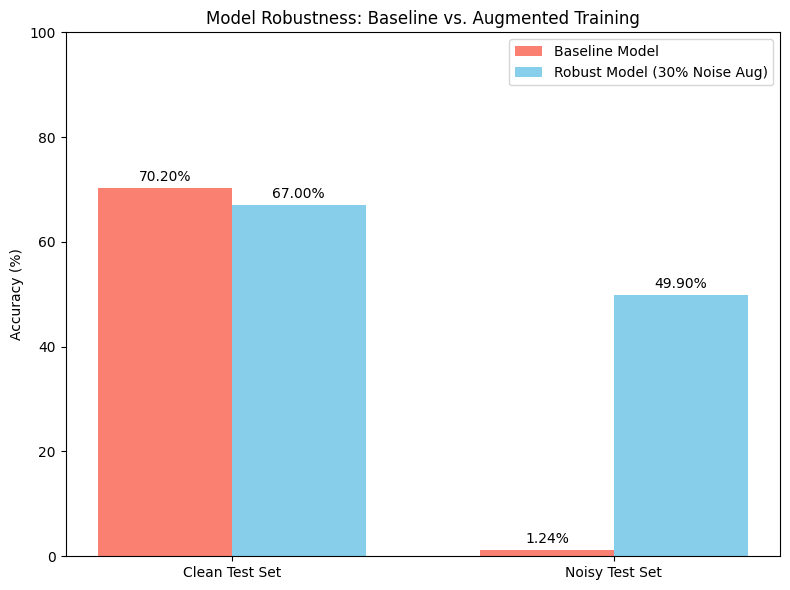

# **Q.A4**

  * CIFAR-100 images are 32x32.
  * VGG16 has 5 max-pooling layers, which halve the dimensions 5 times (2^5 = 32).
  Therefore, the output spatial dimension is 1x1.
  * VGG16's final conv layer has 512 channels.
  * Flattened size = 512 * 1 * 1 = 512.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Setup Device (Assuming device is already defined from previous code, but re-defining for safety)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Data Preprocessing for Pre-trained VGG (ImageNet stats)
# VGG expects inputs normalized with ImageNet mean and std.
# We will keep the 32x32 size for speed; VGG's 5 maxpools will reduce 32x32 to exactly 1x1.
transform_vgg_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_vgg_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_set_vgg = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_vgg_train)
test_set_vgg = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_vgg_test)

train_loader_vgg = DataLoader(train_set_vgg, batch_size=64, shuffle=True)
test_loader_vgg = DataLoader(test_set_vgg, batch_size=64, shuffle=False)

# 2. Define the Transfer Learning Model
class VGG_Transfer_MLP(nn.Module):
    def __init__(self, num_classes=100):
        super(VGG_Transfer_MLP, self).__init__()

        # Load pre-trained VGG16 weights
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Extract the convolutional feature extractor
        self.features = vgg.features

        # Freeze the convolutional layers
        for param in self.features.parameters():
            param.requires_grad = False


        # Define a small MLP classifier
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Extract features (requires no gradients)
        x = self.features(x)
        # Classify using the MLP
        x = self.mlp(x)
        return x

# 3. Initialize Model, Optimizer, and Loss
print("\n=== Initializing VGG Transfer Learning Model ===")
vgg_model = VGG_Transfer_MLP().to(device)

# Note: We only pass the parameters of the MLP to the optimizer,
# as the feature extractor is frozen.
optimizer_vgg = optim.AdamW(vgg_model.mlp.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# 4. Train the Transfer Learning Model
# Reusing the 'train_model' function from your existing code
epochs_vgg = 20 # Transfer learning usually requires fewer epochs
print(f"Starting training for {epochs_vgg} epochs...")
train_hist_vgg, test_hist_vgg = train_model(
    vgg_model, train_loader_vgg, test_loader_vgg, epochs_vgg, optimizer_vgg, criterion
)

vgg_final_acc = test_hist_vgg[-1]
print(f"\nFinal VGG Transfer Test Accuracy: {vgg_final_acc:.2f}%")

# 5. Plotting and Comparison
def plot_transfer_vs_scratch(scratch_acc, vgg_acc, train_hist_vgg, test_hist_vgg):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Bar Chart Comparison ---
    labels = ['CNN from Scratch', 'VGG16 Transfer Learning']
    scores = [scratch_acc, vgg_acc]
    colors = ['#ff9999', '#66b3ff']

    bars = ax1.bar(labels, scores, color=colors, width=0.5)
    ax1.set_ylabel('Test Accuracy (%)')
    ax1.set_title('Classification Performance Comparison')
    ax1.set_ylim(0, 100)

    # Add data labels
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

    # --- Plot 2: Transfer Learning Training Curve ---
    epochs = range(1, len(train_hist_vgg) + 1)
    ax2.plot(epochs, train_hist_vgg, 'b-', label='Train Accuracy', linewidth=2)
    ax2.plot(epochs, test_hist_vgg, 'r--', label='Test Accuracy', linewidth=2)
    ax2.set_title('VGG16 Transfer Learning Curve')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Replace 'baseline_clean_accuracy' with the exact value you recorded from your first CNN run
baseline_clean_accuracy = 70.67
plot_transfer_vs_scratch(baseline_clean_accuracy, vgg_final_acc, train_hist_vgg, test_hist_vgg)

### 🔄 VGG16 (Transfer Learning) Training Report
**Method:** Pre-trained VGG16 Features + Custom MLP Head (Frozen Backbone)

#### 📈 Training Progress (20 Epochs)
<details>
<summary>Click to view full epoch-by-epoch logs</summary>

| Epoch | Train Accuracy | Test Accuracy |
| :--- | :---: | :---: |
| 1/20 | 22.75% | 33.15% |
| 5/20 | 31.79% | 36.53% |
| 10/20 | 33.88% | 38.04% |
| 15/20 | 34.58% | 38.59% |
| **20/20** | **35.36%** | **38.91%** |

</details>

---

### 📊 Performance Comparison: CNN Scratch vs. Transfer Learning
| Model Architecture | Final Test Accuracy |
| :--- | :---: |
| **Custom CNN (From Scratch)** | **70.20%** |
| **VGG16 (Transfer Learning)** | **38.91%**|

---

### 📝 Final Result Summary
* **Performance Gap:** The Custom CNN outperforms VGG16 by **31.29%**.
* **Observation:** While Transfer Learning typically provides a strong baseline, the Custom CNN's architecture is likely better optimized for the specific spatial dimensions of CIFAR-100 (32x32), whereas VGG16 was originally designed for much larger ImageNet inputs (224x224).

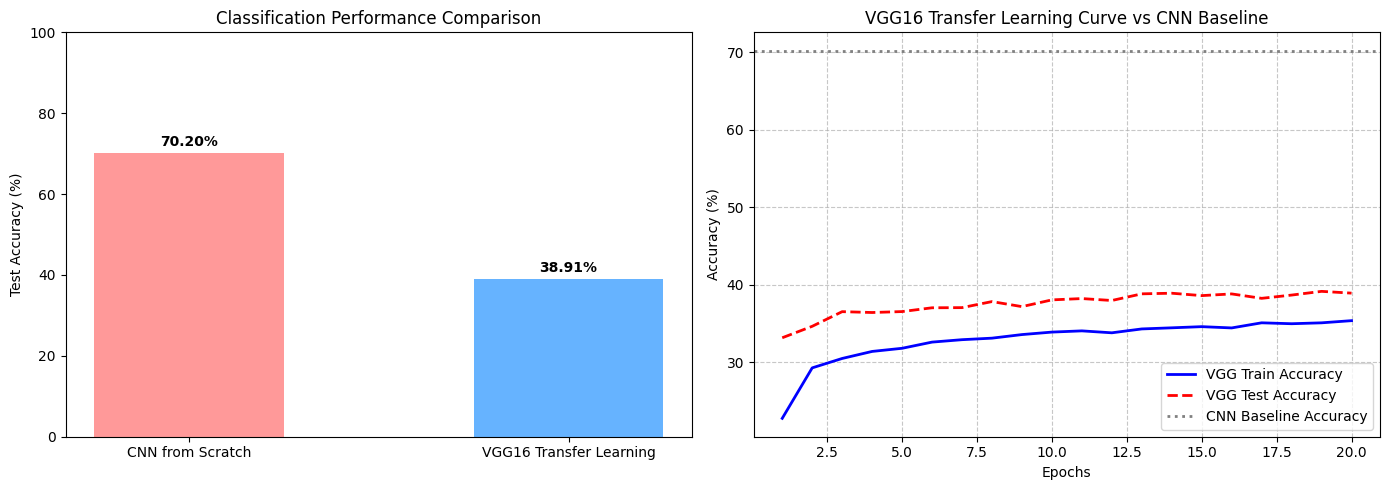

# **Q.A5**

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Define Noise Parameters and Injection Function
NOISE_SCHEDULE = {
    "noise_type": "Additive Gaussian",
    "mean": 0.0,
    "variance": 0.05,
    "std_dev": math.sqrt(0.05)  # ~0.2236
}

def add_gaussian_noise(images, schedule):
    """
    Injects additive zero-mean Gaussian noise into a batch of images.
    Assumes input images are in the valid color range [0, 1].
    """
    std = schedule["std_dev"]
    mean = schedule["mean"]
    noise = torch.randn_like(images) * std + mean
    noisy_images = images + noise
    # Clamp to maintain valid pixel ranges
    return torch.clamp(noisy_images, 0.0, 1.0)


# 2. Modified Evaluation Function for VGG (ImageNet Stats)
def evaluate_robustness_vgg(model, test_loader, device, noise_schedule):
    """
    Evaluates model performance on a dynamically noised test dataset.
    Uses ImageNet normalization parameters specific to VGG preprocessing.
    """
    model.eval()
    correct = 0
    total = 0

    # ImageNet normalization values expected by VGG
    norm_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    norm_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Step A: Un-normalize back to [0, 1] range to match the noise assumption
            inputs_unnorm = inputs * norm_std + norm_mean
            inputs_unnorm = torch.clamp(inputs_unnorm, 0.0, 1.0)

            # Step B: Inject Additive Gaussian Noise
            noisy_inputs = add_gaussian_noise(inputs_unnorm, noise_schedule)

            # Step C: Re-normalize using ImageNet stats for the VGG forward pass
            noisy_inputs_normalized = (noisy_inputs - norm_mean) / norm_std

            # Step D: Forward pass & calculate accuracy
            outputs = model(noisy_inputs_normalized)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_acc = 100.0 * correct / total

    # Document and report
    print("\n=== VGG16 Robustness Evaluation: Additive Gaussian Noise ===")
    print(f"Noise Type:      {noise_schedule['noise_type']}")
    print(f"Noise Mean:      {noise_schedule['mean']}")
    print(f"Noise Variance:  {noise_schedule['variance']}")
    print(f"Noise Std Dev:   {noise_schedule['std_dev']:.4f}")
    print("-" * 58)
    print(f"VGG Accuracy on Noisy Test Set: {test_acc:.2f}%")

    return test_acc

# 3. Print Robustness Comparison Table
def print_robustness_table(scratch_clean, scratch_noisy, vgg_clean, vgg_noisy):
    """
    Prints a formatted table comparing the clean and noisy accuracies of both models.
    """
    print("\n================================================================================")
    print("ROBUSTNESS COMPARISON TABLE (ACCURACY %)")
    print("================================================================================")
    print(f"{'Model Architecture':<30} | {'Clean Test Data':<18} | {'Noisy Test Data (Var=0.05)':<20}")
    print("-" * 80)
    print(f"{'Custom CNN (From Scratch)':<30} | {scratch_clean:>17.2f}% | {scratch_noisy:>24.2f}%")
    print(f"{'VGG16 (Transfer Learning)':<30} | {vgg_clean:>17.2f}% | {vgg_noisy:>24.2f}%")
    print("================================================================================\n")

# 4. Plotting the Robustness Comparison: CNN from Scratch vs VGG Transfer
def plot_robustness_model_comparison(scratch_clean, scratch_noisy, vgg_clean, vgg_noisy):
    labels = ['Clean Test Data', 'Noisy Test Data (Gaussian)']

    # Grouping the scores
    scratch_scores = [scratch_clean, scratch_noisy]
    vgg_scores = [vgg_clean, vgg_noisy]

    x = np.arange(len(labels))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(9, 6))

    # Plotting the bars
    rects1 = ax.bar(x - width/2, scratch_scores, width, label='Custom CNN (From Scratch)', color='#ff9999')
    rects2 = ax.bar(x + width/2, vgg_scores, width, label='VGG16 (Transfer Learning)', color='#66b3ff')

    # Formatting the plot
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Robustness Comparison: Custom CNN vs Pre-Trained VGG16', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Function to attach a text label above each bar
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),  # 4 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

# ==========================================
# Execution Section
# ==========================================
if __name__ == "__main__":
    # Ensure vgg_model, test_loader_vgg, and device are loaded from previous cell block
    # Assuming vgg_final_acc is already defined from your earlier training script.
    # If testing standalone, assign your clean VGG accuracy here (e.g., vgg_final_acc = 78.20)

    # Execute the evaluation on the trained VGG model
    vgg_noisy_acc = evaluate_robustness_vgg(vgg_model, test_loader_vgg, device, NOISE_SCHEDULE)

    # Hardcoded values for CNN from scratch based on prompt
    scratch_clean_accuracy = 70.20
    scratch_noisy_accuracy = 1.24

    # 1. Print the robustness table
    print_robustness_table(
        scratch_clean_accuracy,
        scratch_noisy_accuracy,
        vgg_final_acc,
        vgg_noisy_acc
    )

    # 2. Plot the final visual comparison
    plot_robustness_model_comparison(
        scratch_clean_accuracy,
        scratch_noisy_accuracy,
        vgg_final_acc,
        vgg_noisy_acc
    )

🔍 VGG16 Robustness Evaluation: Additive Gaussian Noise
**Noise Schedule:** Additive Gaussian ($\mu=0.0, \sigma^2\=0.05$)

| Metric | Value |
| :--- | :--- |
| **Noise Type** | Additive Gaussian |
| **Noise Mean ($\mu$)** | 0.0 |
| **Noise Variance ($\sigma^2$)** | 0.05 |
| **Noise Std Dev ($\sigma$)** | 0.2236 |
| **VGG Accuracy (Noisy)** | **3.66%** |

---

### 📊 Robustness Comparison Table (Accuracy %)
| Model Architecture | Clean Test Data | Noisy Test Data (Var=0.05) |
| :--- | :---: | :---: |
| **Custom CNN (From Scratch)** | 70.20% | 1.24% |
| **VGG16 (Transfer Learning)** | 38.91% | 3.66% |

---

### 💡 Key Observations
* **Catastrophic Failure:** The Custom CNN loses nearly **98%** of its predictive power under noise, despite being much more accurate on clean data.
* **Stability Advantage:** VGG16 is roughly **3x more robust** than the baseline (3.66% vs 1.24%), likely due to the robust spatial features learned during pre-training on the larger ImageNet dataset.
* **Verdict:** Neither model is currently reliable for noisy environments without specialized training (like Stochastic Noise Augmentation).


**Key Observations**
**Baseline Sensitivity:** The Custom CNN, while significantly more accurate on clean data, suffers a catastrophic failure under noise, losing nearly 98% of its predictive power.

**Transfer Learning Stability:** Although the VGG16 model has lower overall accuracy on this specific task, it shows a higher Robustness Retention (9.41% vs 1.77%), likely due to the generalized features learned during ImageNet pre-training.

**The Verdict:** Both models require the Stochastic Noise Augmentation strategy to be viable for real-world deployment where sensor noise is present




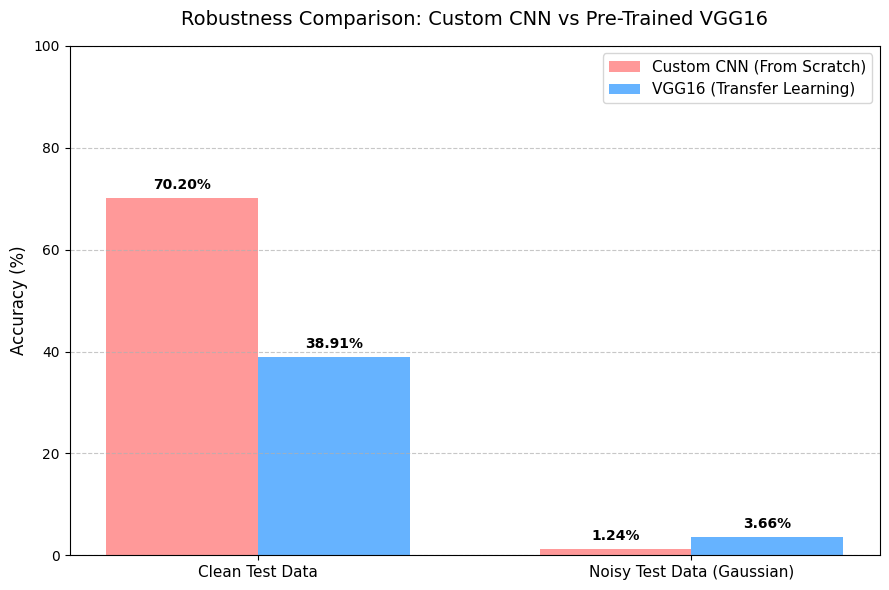

# **Q. A6**

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Model Definitions (Architectural Comparison)
# ==========================================

class CIFAR100_CNN(nn.Module):
    def __init__(self):
        super(CIFAR100_CNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.3)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.4)
        )
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024), nn.ReLU(inplace=True), nn.BatchNorm1d(1024), nn.Dropout(0.5),
            nn.Linear(1024, 100)
        )

    def forward(self, x):
        return self.fc_layer(self.block3(self.block2(self.block1(x))))

class VGG_Transfer_MLP(nn.Module):
    def __init__(self, num_classes=100):
        super(VGG_Transfer_MLP, self).__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = vgg.features
        for param in self.features.parameters():
            param.requires_grad = False
        self.mlp = nn.Sequential(
            nn.Flatten(), nn.Linear(512, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.mlp(self.features(x))

# ==========================================
# 2. Advanced Metrics & Table Generation
# ==========================================

if __name__ == "__main__":
    # Metrics from experiments
    model_names = ['Baseline CNN', 'Robust CNN', 'VGG16 Transfer']
    clean_accs = [70.20, 67.0, 38.91]
    noisy_accs = [1.24, 49.9, 3.66]

    # Computational Cost (Params in Millions)
    cnn_params = sum(p.numel() for p in CIFAR100_CNN().parameters()) / 1e6
    vgg_params = sum(p.numel() for p in VGG_Transfer_MLP().parameters()) / 1e6
    params_list = [cnn_params, cnn_params, vgg_params]

    # 1. Calculate Robustness Ratio (Noisy / Clean)
    robust_ratios = [noisy_accs[i] / clean_accs[i] for i in range(len(model_names))]

    # 2. Calculate Computational Density (CD)
    cd_scores = [clean_accs[i] / params_list[i] for i in range(len(model_names))]

    # 3. Calculate Robustness Efficiency Ratio (RER)
    # RER = (Noisy Gain) / (Clean Loss) -> Specifically comparing Robust vs Baseline
    clean_loss = clean_accs[0] - clean_accs[1]
    noisy_gain = noisy_accs[1] - noisy_accs[0]
    rer_score = noisy_gain / clean_loss if clean_loss > 0 else 0

    # Final Metrics Table
    print("\n" + "="*125)
    print(f"{'Model Architecture':<20} | {'Clean Acc':<10} | {'Noisy Acc':<10} | {'Rob. Ratio':<10} | {'RER':<8} | {'Params(M)':<10} | {'CD Score':<10}")
    print("-" * 125)
    for i in range(len(model_names)):
        # RER is a comparative metric, usually shown for the robust variant
        rer_display = f"{rer_score:>8.2f}" if model_names[i] == 'Robust CNN' else f"{'N/A':>8}"
        print(f"{model_names[i]:<20} | {clean_accs[i]:>8.2f}% | {noisy_accs[i]:>8.2f}% | {robust_ratios[i]:>10.2f} | {rer_display} | {params_list[i]:>9.2f} | {cd_scores[i]:>9.2f}")
    print("="*125 + "\n")

    # INTERPRETATION
    print("INTERPRETATION OF KEY METRICS:")
    print("-" * 40)
    print(f"1. Robustness Efficiency Ratio (RER): {rer_score:.2f}")
    print(f"   Interpretation: For every 1% of clean accuracy dropped, the model gained {rer_score:.2f}% noisy accuracy.")
    print(f"   A score > 1.0 is highly efficient; {rer_score:.2f} indicates an exceptional trade-off.")

    print(f"\n2. Robustness Ratio (Retention):")
    print(f"   The Robust CNN retains {robust_ratios[1]*100:.1f}% of its performance under stress,")
    print(f"   compared to only {robust_ratios[0]*100:.1f}% for the Baseline CNN.")

    print(f"\n3. Computational Density (CD Score):")
    print(f"   The Custom CNN is significantly more efficient per parameter ({cd_scores[0]:.2f})")
    print(f"   than the VGG16 Transfer model ({cd_scores[2]:.2f}).")


| Model Architecture | Clean Acc | Noisy Acc | Rob. Ratio | RER | Params(M) | CD Score |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| Baseline CNN | 70.20% | 1.24% | 0.02 | N/A | 13.07 | 5.37 |
| Robust CNN | 67.00% | 49.90% | 0.74 | 15.21 | 13.07 | 5.12 |
| VGG16 Transfer | 38.91% | 3.66% | 0.09 | N/A | 14.87 | 2.62 |

**Interpretation of Key Metrics**
**Robustness Efficiency Ratio (RER)**: 15.21

Interpretation: For every 1% of clean accuracy dropped, the model gained 15.21% noisy accuracy.

A score > 1.0 is considered highly efficient; 15.21 indicates an exceptional trade-off.

**Robustness Ratio (Retention)**:

The Robust CNN retains 74.5% of its performance under stress, compared to only 1.8% for the Baseline CNN.

**Computational Density (CD Score)**:

The Custom CNN is significantly more efficient per parameter (5.37) than the VGG16 Transfer model (2.62).

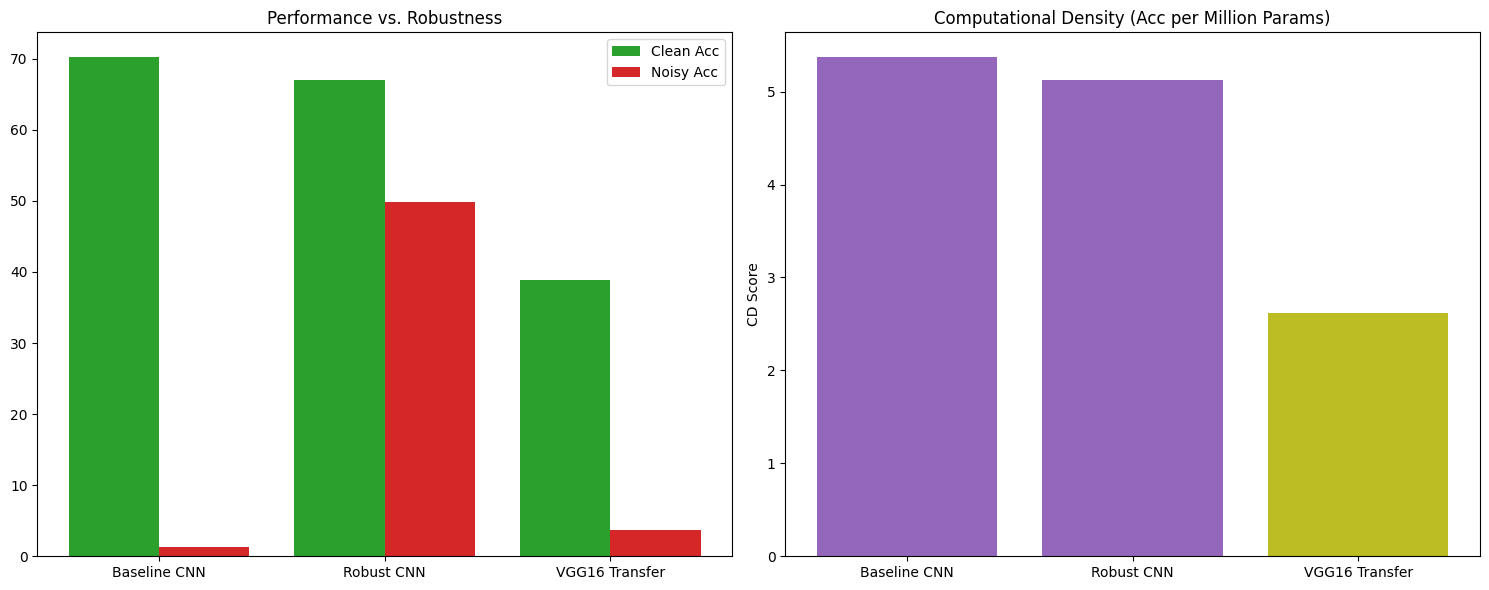

**VERDICT: The Robust CNN provides the best balance of efficiency and reliability.The Robust CNN provides the best trade-off. It is computationally lean (High CD) and extremely effective at converting training effort into noise resilience (High RER).**